# ORBIT INDUCTIONS - NIRAV KARAHE (106125079)

# TASK 1 (VIDEOS)

## Learnings

- Through these videos, I learned how machine learning models learn patterns from data instead of relying on fixed rules.
- I also understood the difference between supervised and unsupervised learning and the  importance of avoiding overfitting.
- In OpenCV, I learned how images are represented as numerical data and how color spaces affect image processing.
- Concepts like thresholding and edge detection showed how computers extract meaningful information from images.

# TASK 2 (ALTITUDE PREDICTION MODEL)

The task is to train models given the data from the csv file and compare the different models using metrics. Using this project we can then understand which model is the most accurate at predicting altitudes given data from the sensors.
Using the model we can then improve further trials.

## Import Important Libraries

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

## Reading CSV File
- Printing first 5 Rows
- Information on every Column

## Inferences
Total Columns 5:
- Time (with 780 not null values)
- Velocity (with 748 not null values)
- Acceleration (759 not null values)
- Pressure (759 not null values)
- Altitude (779 not null values)

All Datatypes are float64 

In [56]:
df = pd.read_csv('/Users/niravkarahe/Desktop/Orbit Inductions/rocket_launch_data.csv')
print(df.head())
print(df.info())

   Time(s)  Velocity(m/s)  Accel(m/s^2)  Pressure(kPa)  Altitude(m)
0  0.00000       0.600000      0.600000     101.220000     0.600000
1  0.06006       0.637838      0.601802     101.269249     0.673874
2  0.12012       0.675676           NaN     101.318499     0.747748
3  0.18018            NaN      0.605405     101.367748     0.821622
4  0.24024       0.751351      0.607207     101.416997     0.895495
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Time(s)        780 non-null    float64
 1   Velocity(m/s)  748 non-null    float64
 2   Accel(m/s^2)   759 non-null    float64
 3   Pressure(kPa)  759 non-null    float64
 4   Altitude(m)    779 non-null    float64
dtypes: float64(5)
memory usage: 32.0 KB
None


## Fixing Not Null Values issue

New dataframes df1 and df2 where df1 is dataframe in which all NaN rows are dropped and df2 where interpolation is done (with polynomial method) to figure out and replace null values. (Mistake recitifed at the end)

In [57]:
df1 = df.dropna()
print(df1.info())

df2 = df.copy()
for column in df2.columns:
    df2[column] = df2[column].fillna(df2[column].interpolate(method = 'polynomial', order = 2))
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
Index: 631 entries, 0 to 814
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Time(s)        631 non-null    float64
 1   Velocity(m/s)  631 non-null    float64
 2   Accel(m/s^2)   631 non-null    float64
 3   Pressure(kPa)  631 non-null    float64
 4   Altitude(m)    631 non-null    float64
dtypes: float64(5)
memory usage: 29.6 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Time(s)        815 non-null    float64
 1   Velocity(m/s)  815 non-null    float64
 2   Accel(m/s^2)   815 non-null    float64
 3   Pressure(kPa)  815 non-null    float64
 4   Altitude(m)    815 non-null    float64
dtypes: float64(5)
memory usage: 32.0 KB
None


## Plots and Correlations
Plotting all different columns vs Altitude to see how they change with respect to altitude, to then figure out which parameters are best to use to judge and predict Altitude.

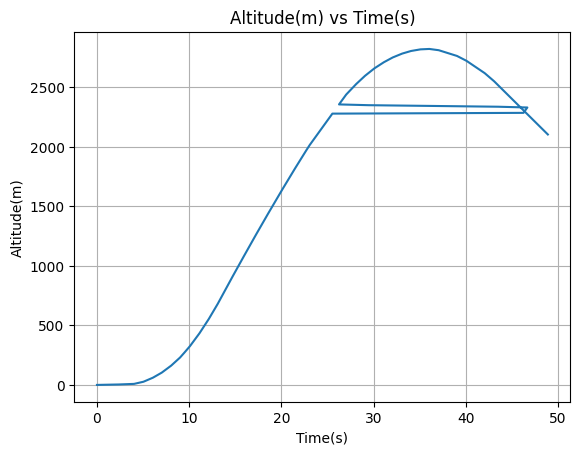

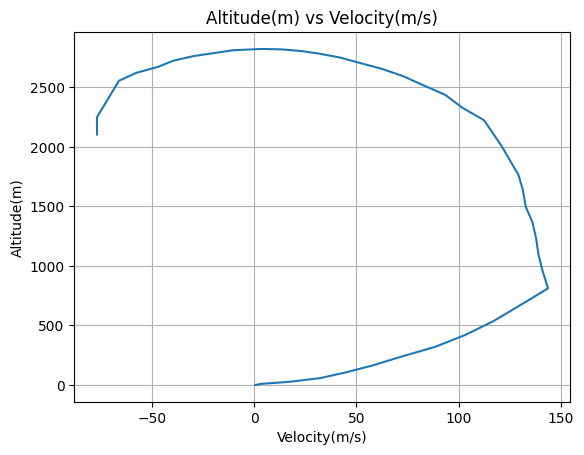

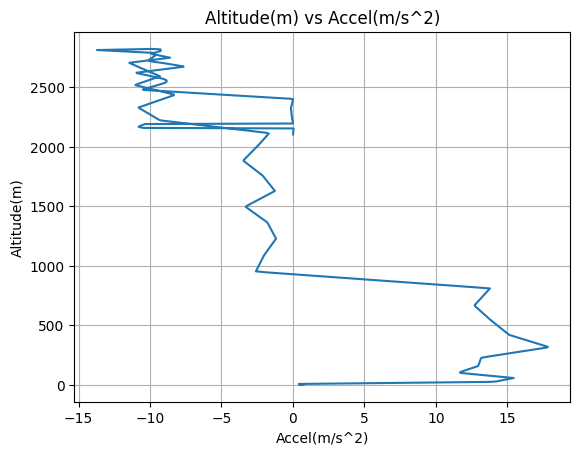

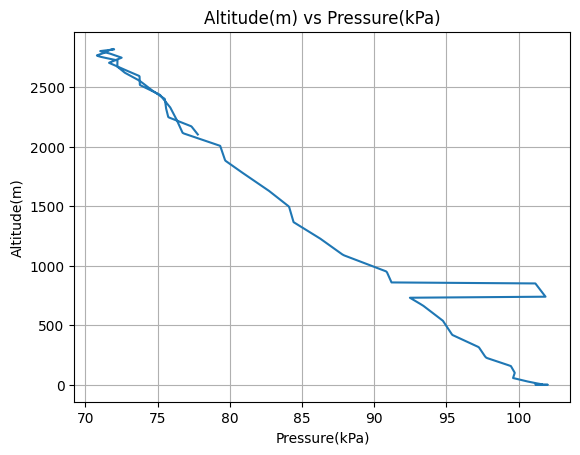

                Time(s)  Velocity(m/s)  Accel(m/s^2)  Pressure(kPa)  \
Time(s)        1.000000      -0.606773     -0.650733      -0.884521   
Velocity(m/s) -0.606773       1.000000      0.286742       0.323305   
Accel(m/s^2)  -0.650733       0.286742      1.000000       0.836280   
Pressure(kPa) -0.884521       0.323305      0.836280       1.000000   
Altitude(m)    0.889899      -0.332711     -0.837493      -0.990305   

               Altitude(m)  
Time(s)           0.889899  
Velocity(m/s)    -0.332711  
Accel(m/s^2)     -0.837493  
Pressure(kPa)    -0.990305  
Altitude(m)       1.000000  


In [58]:
col = df1.columns
y = "Altitude(m)"
for x in col:
    if x != y:
        plt.figure()
        plt.plot(df2[x], df2[y])
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(f"{y} vs {x}")
        plt.grid(True)
        plt.show()
print(df1.corr())

## Inferences

Time(s)           0.889899  
Velocity(m/s)    -0.332711  
Accel(m/s^2)     -0.837493  
Pressure(kPa)    -0.990305 

Using above correlations with respect to Altitude we see that Pressure is almost a 100% related while Time and Accelerations are pretty closely related to altitude but velocity on the other hand is very unrelated to altitude at only -0.33.

Also looking at the plots we see a smooth curve for Altitude vs Time (other than a few exceptional points) and Altitude vs Pressure (almost linearly dependent curve) while Altitude vs Acceleration is very jagged and seems unreliable

## Choosing The Parameters
Based on above inferences the following parameters seem best to be used:
- Pressure (Good Plot and Highest Correlation) (Most Reliable)
- Time (Smooth Plot and Decent Correlation)
- Acceleration (Can be used if needed be because the graph was not the best but correlation is 83%)

Higher correlation relates to better predictabiility and a smoother plot would indicate better consistency in relation to altitude.
Also talking physics-wise Pressure decreases as altitude increases in an almost perfectly inverse relation meanwhile time and acceleration would change frequently and sometimes unpredictably but still would be good supporting features.

## Splitting/Scaling/Testing Models

Here I am going to test the following models:
- Linear Regression
- Random Forest
- K-Nearest Neighbours (KNN)
- Support Vector Regression (SVR)

First we need to split the given data into test and train data. As the name suggests we will use the train data to train the model and then once trained we will use the test data values to see how accurate the models are using different metrics and testing methods.

Here the test data size is 20% of the total data and train data size is 80%, also I used a random state 67 (lol) because I want reproducibility every time I run the model.

We will represent the features with X and the target (to be predicted) with y as commonly done.

In [59]:
X = df1[['Time(s)', 'Accel(m/s^2)', 'Pressure(kPa)']]
y = df1['Altitude(m)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

## Explaining all models and prerequisites along with pros and cons for each

### Linear Regression 
A very simple model, which assumes that the given data has a linear relationship between the features and the target. So it figures out the slopes and learns coefficients and predicts on the basis of these coefficients. The predicted value is a weighted sum of the features.
It works best when the relation is linear but for curves in plots it fails.

#### Pros
- Easy, Simple and Fast to train
- Good with small datasets
#### Cons
- Assumes linear relationship so predictions are mostly flawed when relations are not linear
- Prone to underfitting (Low complexity)

### Random Forest
Basically works with many decision trees. Decision trees are a set of if-else questions that the dataset is exposed to and based on the question the dataset is spit into smaller groups. Along with this the predictions are averaged to reduce the effect of overfitting.

#### Pros
- No need to scale the features (If the ranges of features are different then normally distance based algorithms are biased towards higher ranged features).
- Good model for both Classification (Fixed outputs) or Regression.

#### Cons
- Prone to overfitting (Sometimes overly complex method so it focuses heavily on the outliers and affects the final predictions)
- Needs good amount of data

### Support Vector Regression (SVR)
This algorithm tries to create a function between the given features and target, could be linear, polynomial or any non linear function if kernels are used which dimentionalise the features to create flexibility. The features are allowed to influence the predictions if they are within a certain limit of error of the already defined function. Otherwise if the feature is outside the error limit, it is "taxed" and looked at as an outlier. This is also one of the reasons why scaling is critically important here because the tolerance is mapped by distance and so larger ranged features would be heavily influencing the resultant prediction.

#### Pros
- Can model non linear relations using kernals
- Flexible tolerance

#### Cons
- Slow for large datasets
- Sensitive to scaling of features

### K-Nearest-Neighbours (KNN)
Makes predictions based on the K nearest datapoints in the dataset(training) and takes an average or vote for either regression or classification.
Of course for the same reason scaling is very necessary here as well, since euclidean distance is considered for the K closest points.

#### Pros
- Can model non linear relationships
- Works for both classification and regression
- Can choose manually the number of nearest neighbours to be looked at

#### Cons
- Slow
- Sensitive to irrelevant features and requires scaling

## Metrics
- Mean Absolute Error (MAE)
    - Just average of difference between predicted and actual y value
- Root Mean Squared Error (RMSE)
    - Finding RMS distance between the y_predicted value and the actual y value
- R2 Score
    - Comparing our model to another which only predicts the mean of the actual y value.

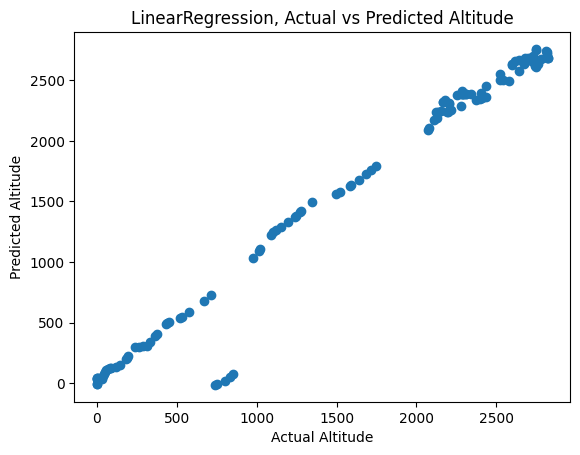

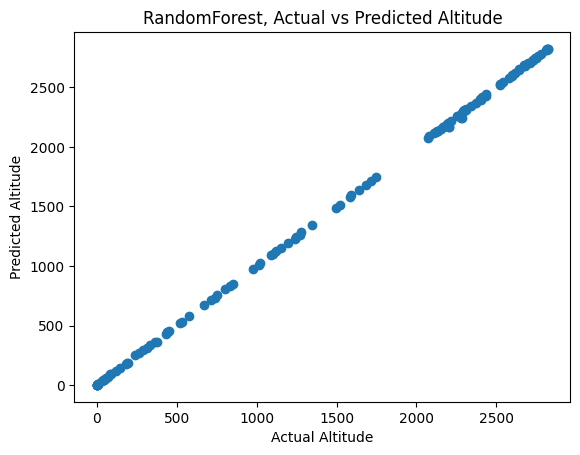

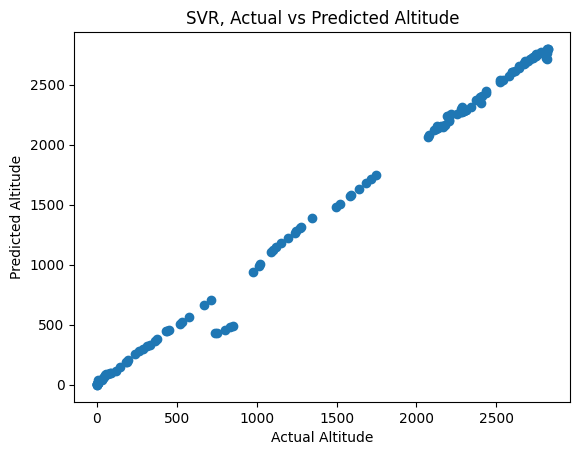

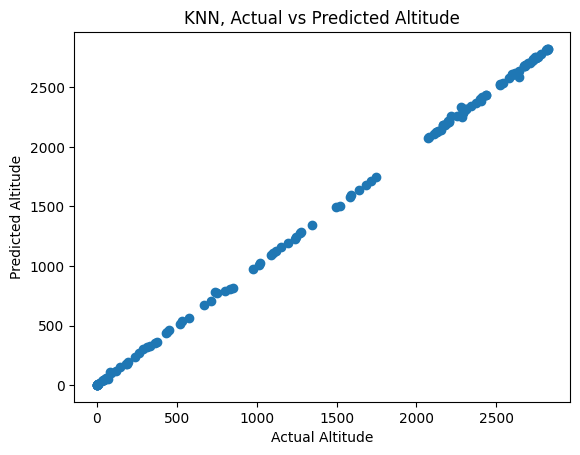

             Models  Mean Absolute Error  Root Mean Squared Error  R2 Score
0  LinearRegression            88.872240               169.928876  0.972513
1      RandomForest             4.366178                 8.525154  0.999931
2               SVR            26.614287                70.086830  0.995324
3               KNN             7.042778                12.173044  0.999859


In [60]:
#Scaled Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Models
models = {
    'Linear Regression': LinearRegression(fit_intercept=True),
    'Random Forest': RandomForestRegressor(n_estimators = 200,random_state=67),
    'SVR': SVR(kernel = "rbf", C=100, gamma="scale", epsilon=.1),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=7, weights='distance', metric='euclidean')
}

def eval(name, model, Xtrain, Xtest):
    model.fit(Xtrain, y_train) #Fit the model to the training data
    predictions = model.predict(Xtest)  #Make predictions on the test data

    plt.figure()
    plt.scatter(y_test, predictions)
    plt.xlabel("Actual Altitude")
    plt.ylabel("Predicted Altitude")
    plt.title(f"{name}, Actual vs Predicted Altitude")
    plt.show()

    mean_error = mean_absolute_error(y_test, predictions)
    rms_error = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    return [name, mean_error, rms_error, r2] #Return the evaluation metrics as a list

results = []

#Linear Regression and Random Forest models trained on unscaled features
results.append(eval("LinearRegression", models['Linear Regression'], X_train, X_test))
results.append(eval("RandomForest", models['Random Forest'], X_train, X_test))

#Support Vector Regression and K-Nearest Neighbors models trained on scaled features
results.append(eval("SVR", models['SVR'], X_train_scaled, X_test_scaled))
results.append(eval("KNN", models["K-Nearest Neighbors"], X_train_scaled, X_test_scaled))

results_df = pd.DataFrame(results, columns = ["Models", "Mean Absolute Error", "Root Mean Squared Error", "R2 Score"])
print(results_df)

## Final Inferences/Conclusion
- In this task, multiple regression models were implemented to predict rocket altitude using time, acceleration, and pressure as input features. Linear Regression, Random Forest, Support Vector Regression, and K-Nearest Neighbors were evaluated using Mean Absolute Error, Root Mean Squared Error, and R² score.

- Among these, Random Forest and KNN had the best performance, achieving very low prediction errors and R² values close to 1, indicating high accuracy. 

- My Personal inference after seeing such accurate results was that I might have had data leaks somewhere along the lines, which I did when I used dataframe 2 (with interpolated values) this causes slight data leaks because of the fact that splitting had not occurred until then and that test data was being used to identify train data leaking its influence over it. Therefore I quickly changed to using dataframe 1 where null values were just dropped instead. Still the results were very accurate as you can see above. 

- This does seem to be a case of overfitting but still unlikely because in this case pressure and such features that were used actually have a significant relation to altitude reached, defined by some high order physics so altitude is not something that is much different from the features themselves and so accuracy was bound to be high.


## What If We split first then interpolate?

In [61]:
df = df.dropna(subset=['Altitude(m)'])

features = ['Time(s)', 'Accel(m/s^2)', 'Pressure(kPa)']
target = 'Altitude(m)'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=67
)

X_train = X_train.interpolate(method='polynomial', order=2)
X_test = X_test.interpolate(method='polynomial', order=2)

X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),

    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        random_state=67
    ),

    'SVR': SVR(
        kernel='rbf',
        C=100,
        gamma='scale',
        epsilon=0.1
    ),

    'KNN': KNeighborsRegressor(
        n_neighbors=7,
        weights='distance',
        metric='euclidean'
    )
}

def evaluate(name, model, Xtr, Xte):

    model.fit(Xtr, y_train)

    y_pred = model.predict(Xte)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return [name, mae, rmse, r2]

results = []

# Unscaled models
results.append(evaluate(
    'Linear Regression',
    models['Linear Regression'],
    X_train,
    X_test
))

results.append(evaluate(
    'Random Forest',
    models['Random Forest'],
    X_train,
    X_test
))

# Scaled models
results.append(evaluate(
    'SVR',
    models['SVR'],
    X_train_scaled,
    X_test_scaled
))

results.append(evaluate(
    'KNN',
    models['KNN'],
    X_train_scaled,
    X_test_scaled
))

results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'RMSE', 'R2']
)

print(results_df)


               Model        MAE        RMSE        R2
0  Linear Regression  82.919210  170.717159  0.972308
1      Random Forest   3.525321    5.361290  0.999973
2                SVR  26.225102   71.095061  0.995197
3                KNN   6.752586   11.334048  0.999878


## Inference

Pretty much exactly the same results as above which further proves my point that accuracy is so high only because of the physical relations between the features and target.

# Conclusions

## Key Takeaways

- Data analysis was essential for understanding sensor behavior, especially how altitude changes with given features, and to figure out different outliers and get a general idea of the physical relations.

- Handling missing sensor values can be done through several methods, we can interpolate values(But do it after splitting to testing and training dataset) or drop cells.

- Among the tested models, non-linear models such as Random Forest and SVR captured the complex relationships between sensor readings and altitude better than Linear Regression.

- Feature selection played a critical role, choosing time, pressure and acceleration was crucial for models to work perfectly.

## Challenges Faced

- Noise in the data and missing values were a challenge to solve.

- Some models were sensitive to feature scaling, particularly SVR and KNN, requiring additional preprocessing.

- More correlation between features also leads to redundant data which was the case here so it may have made the model too overconfident

## Improvements with More Data or Time

- Collecting more flight data under varying conditions would improve model generalization and as I said above would make models more practical.

